In [1]:
for (pkg in c("ggplot2", "dplyr", "tidyr")) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                pkg,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}
source("../../utils/r_themes.r")

In [2]:
data_split_data_path <- file.path("../data_splits/train_test_wells.parquet")
umap_coords_file_path <- file.path("../../3.generate_umap_and_PCA/results/UMAP/single-cell_profiles_CP_scDINO_all_timepoints_umap.parquet"
)
data_split_data <- arrow::read_parquet(data_split_data_path)
umap_coords <- arrow::read_parquet(umap_coords_file_path)
# merge the data split information with the UMAP coordinates
merged_data <- dplyr::left_join(umap_coords, data_split_data, by = c("Metadata_Well"))
merged_data$Metadata_Time <- as.numeric(merged_data$Metadata_Time) 
merged_data$Metadata_Time <- as.numeric(merged_data$Metadata_Time) * 30


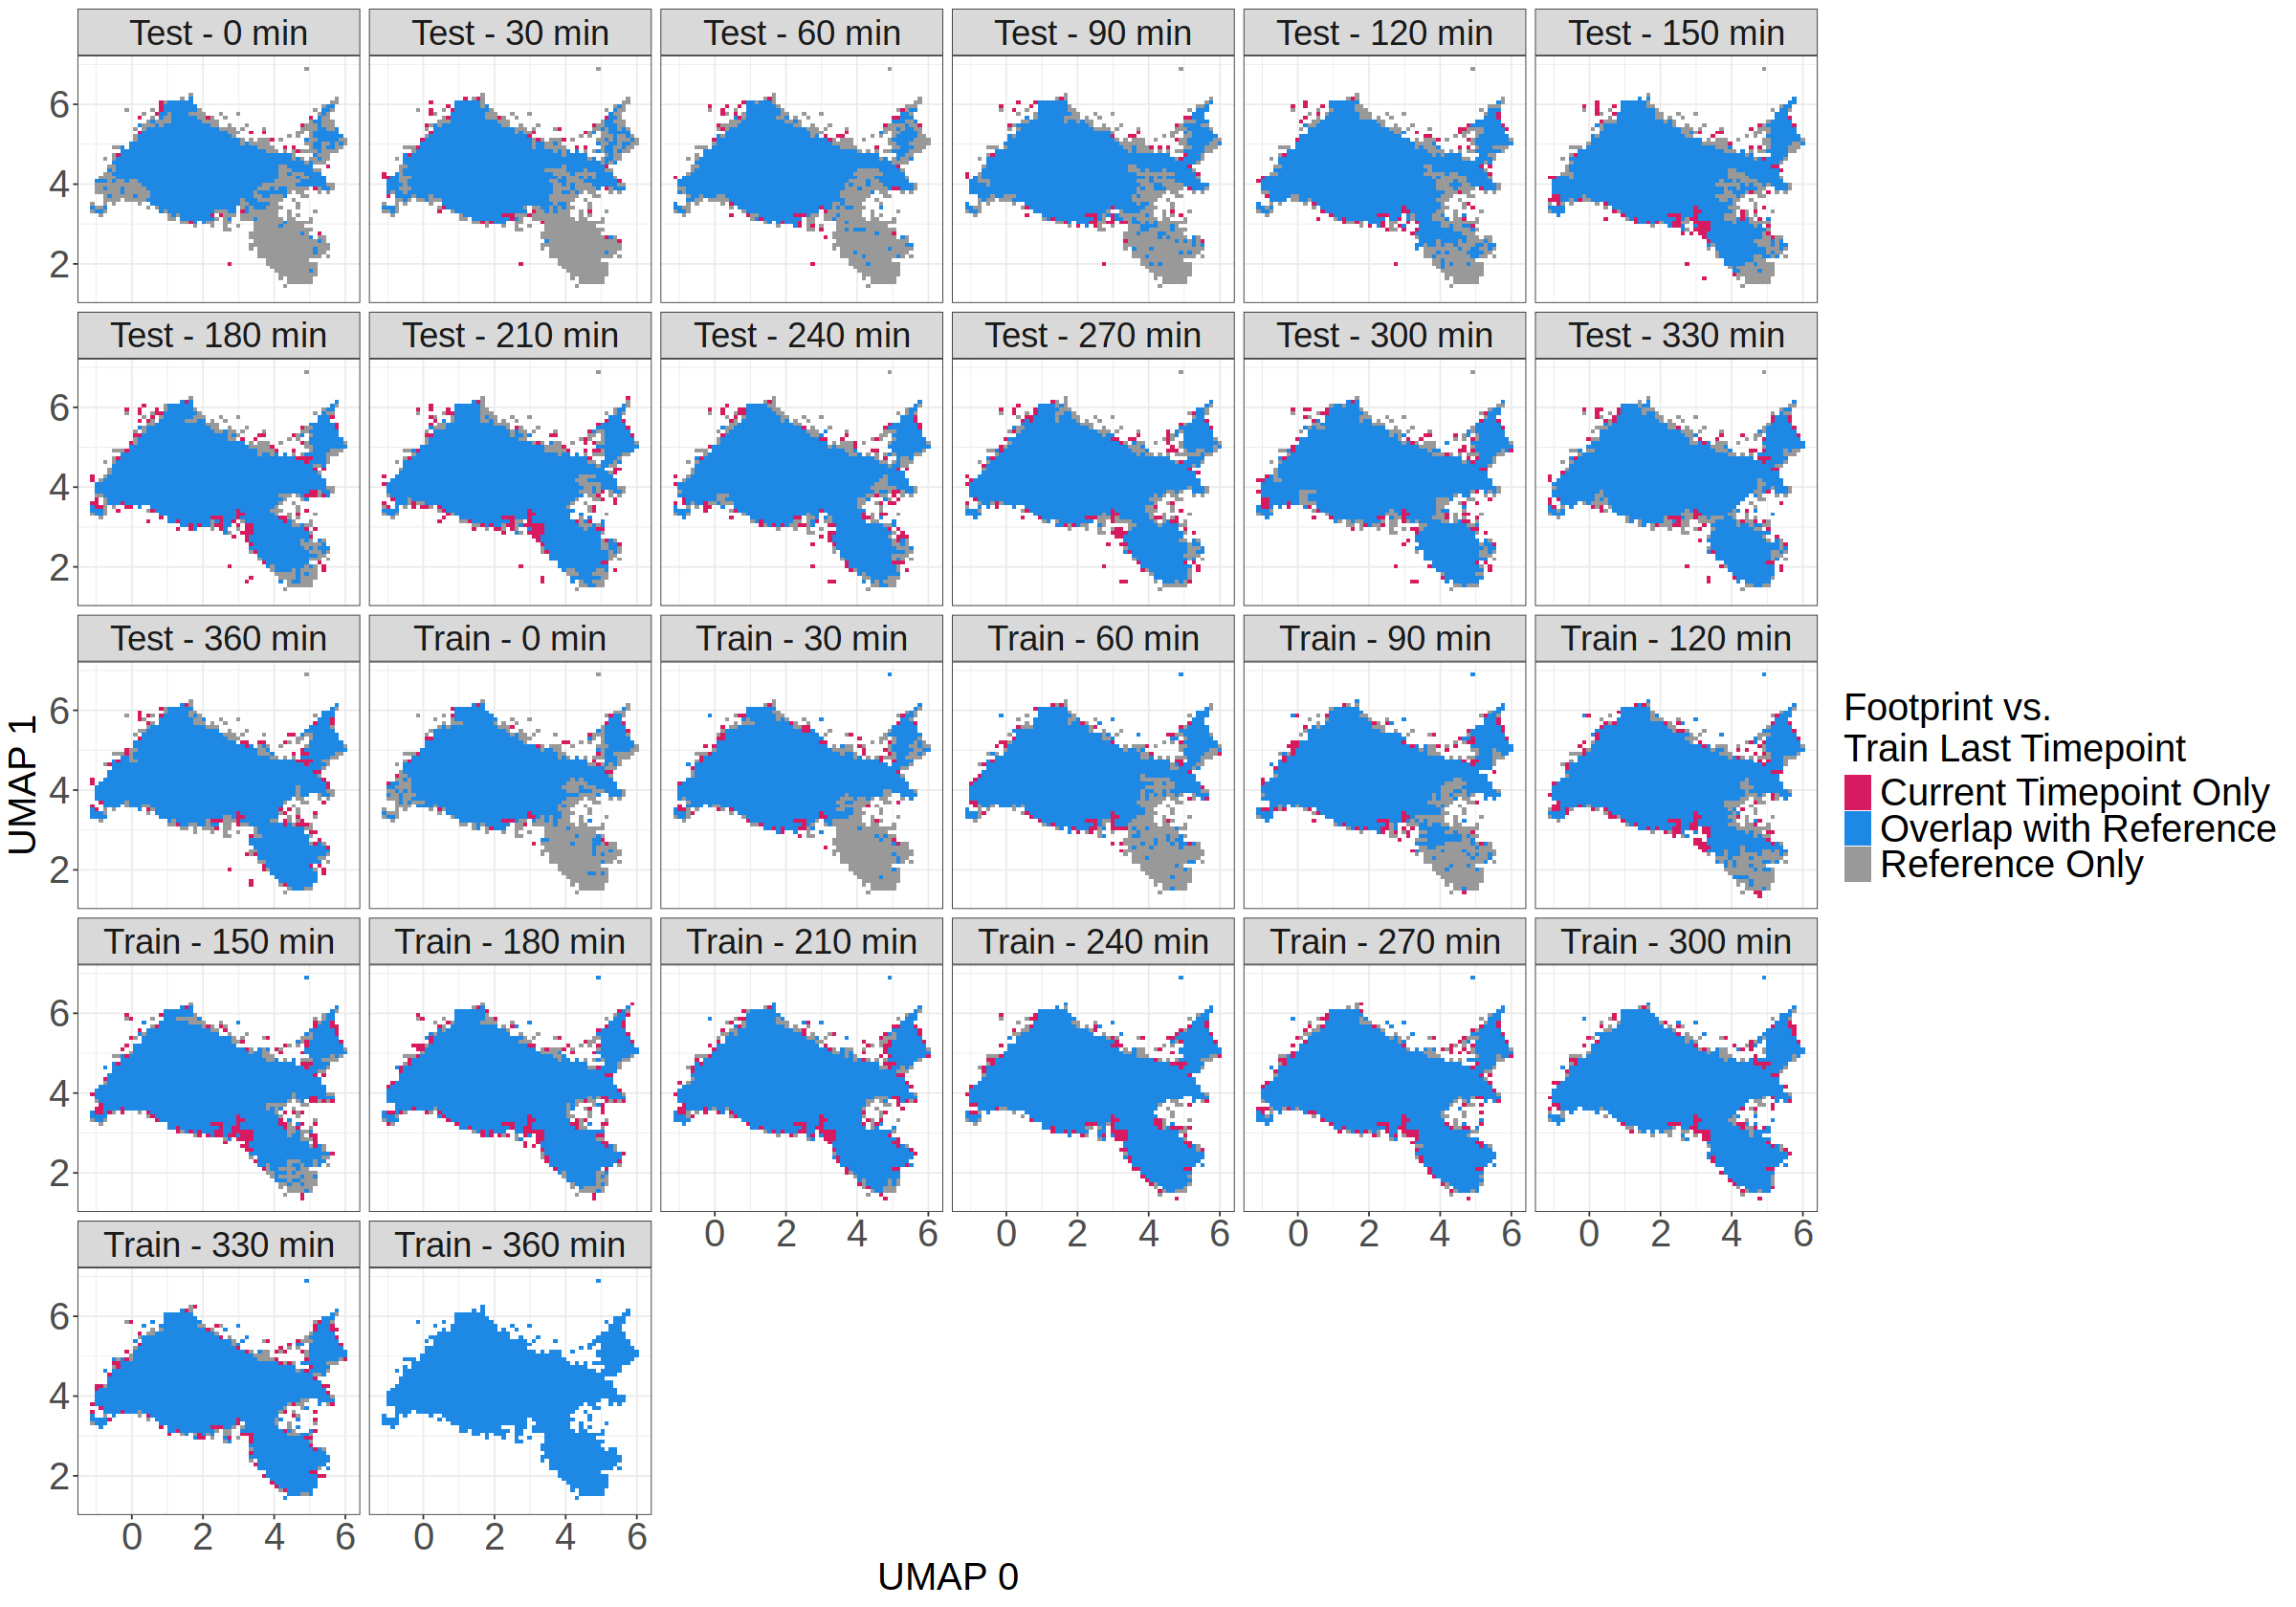

In [3]:
height <- 14
width <- 20
options(repr.plot.width = width, repr.plot.height = height)

# ---- 1. build a shared grid over the full UMAP space ----
n_bins <- 60  # lower than 100 - flood fill + per-group looping gets slow at very high res

x_range <- range(merged_data$UMAP_0, na.rm = TRUE)
y_range <- range(merged_data$UMAP_1, na.rm = TRUE)

x_breaks <- seq(x_range[1], x_range[2], length.out = n_bins + 1)
y_breaks <- seq(y_range[1], y_range[2], length.out = n_bins + 1)
bin_width_x <- diff(x_breaks)[1]
bin_width_y <- diff(y_breaks)[1]

merged_data <- merged_data |>
    dplyr::mutate(
        x_bin = cut(UMAP_0, breaks = x_breaks, include.lowest = TRUE, labels = FALSE),
        y_bin = cut(UMAP_1, breaks = y_breaks, include.lowest = TRUE, labels = FALSE)
    )

# ---- 2. flood-fill helper: fills interior holes of a logical occupancy matrix ----
fill_holes <- function(occ_mat) {
    nr <- nrow(occ_mat); nc <- ncol(occ_mat)
    total <- nr * nc
    outside <- matrix(FALSE, nr, nc)
    visited <- matrix(FALSE, nr, nc)
    queue <- integer(total)
    head <- 1L; tail <- 0L

    seed <- function(idx) {
        if (!occ_mat[idx] && !visited[idx]) {
            visited[idx] <<- TRUE
            tail <<- tail + 1L
            queue[tail] <<- idx
        }
    }
    for (r in c(1, nr)) for (c in seq_len(nc)) seed((c - 1) * nr + r)
    for (c in c(1, nc)) for (r in seq_len(nr)) seed((c - 1) * nr + r)

    while (head <= tail) {
        idx <- queue[head]; head <- head + 1L
        outside[idx] <- TRUE
        r <- ((idx - 1) %% nr) + 1L
        c <- ((idx - 1) %/% nr) + 1L
        if (r > 1)  { nidx <- idx - 1L; if (!occ_mat[nidx] && !visited[nidx]) { visited[nidx] <- TRUE; tail <- tail + 1L; queue[tail] <- nidx } }
        if (r < nr) { nidx <- idx + 1L; if (!occ_mat[nidx] && !visited[nidx]) { visited[nidx] <- TRUE; tail <- tail + 1L; queue[tail] <- nidx } }
        if (c > 1)  { nidx <- idx - nr; if (!occ_mat[nidx] && !visited[nidx]) { visited[nidx] <- TRUE; tail <- tail + 1L; queue[tail] <- nidx } }
        if (c < nc) { nidx <- idx + nr; if (!occ_mat[nidx] && !visited[nidx]) { visited[nidx] <- TRUE; tail <- tail + 1L; queue[tail] <- nidx } }
    }
    occ_mat | !outside
}

make_occ_matrix <- function(x_bin, y_bin, n_bins) {
    mat <- matrix(FALSE, n_bins, n_bins)
    idx <- unique(cbind(x_bin, y_bin))
    idx <- idx[stats::complete.cases(idx), , drop = FALSE]
    mat[cbind(idx[, 1], idx[, 2])] <- TRUE
    mat
}

# ---- 3. reference footprint: train's LAST timepoint, filled solid ----
train_last_time <- max(
    merged_data$Metadata_Time[merged_data$data_split == "train"],
    na.rm = TRUE
)

ref_xy <- merged_data |>
    dplyr::filter(data_split == "train", Metadata_Time == train_last_time)

reference_filled <- fill_holes(make_occ_matrix(ref_xy$x_bin, ref_xy$y_bin, n_bins))

# ---- 4. every (split, timepoint) footprint, filled solid, compared to reference ----
groups <- merged_data |> dplyr::distinct(data_split, Metadata_Time)

footprint_list <- vector("list", nrow(groups))
for (i in seq_len(nrow(groups))) {
    ds <- groups$data_split[i]
    tp <- groups$Metadata_Time[i]
    sub <- merged_data |> dplyr::filter(data_split == ds, Metadata_Time == tp)
    current_filled <- fill_holes(make_occ_matrix(sub$x_bin, sub$y_bin, n_bins))

    df <- expand.grid(x_bin = seq_len(n_bins), y_bin = seq_len(n_bins))
    df$current <- as.vector(current_filled)
    df$reference <- as.vector(reference_filled)
    df$data_split <- ds
    df$Metadata_Time <- tp
    footprint_list[[i]] <- df
}
footprint <- dplyr::bind_rows(footprint_list) |>
    dplyr::filter(current | reference) |>
    dplyr::mutate(
        footprint_type = dplyr::case_when(
            current & reference  ~ "Overlap with Reference",
            current & !reference ~ "Current Timepoint Only",
            !current & reference ~ "Reference Only"
        ),
        UMAP_0 = x_breaks[x_bin] + bin_width_x / 2,
        UMAP_1 = y_breaks[y_bin] + bin_width_y / 2
    )

# ---- 5. panel labels ----
footprint <- footprint |>
    dplyr::mutate(
        panel_label = paste0(
            stringr::str_to_title(data_split), " - ", Metadata_Time, " min"
        ),
        panel_label = factor(
            panel_label,
            levels = footprint |>
                dplyr::distinct(data_split, Metadata_Time) |>
                dplyr::arrange(data_split, Metadata_Time) |>
                dplyr::mutate(lbl = paste0(stringr::str_to_title(data_split), " - ", Metadata_Time, " min")) |>
                dplyr::pull(lbl)
        )
    )

# ---- 6. plot ----
footprint_plot <- (
    ggplot(footprint, aes(x = UMAP_0, y = UMAP_1, fill = footprint_type))
    + geom_tile(width = bin_width_x, height = bin_width_y)
    + scale_fill_manual(
        name = "Footprint vs.\nTrain Last Timepoint",
        values = c(
            "Reference Only"          = "#999999",
            "Current Timepoint Only"  = "#D81B60",
            "Overlap with Reference"  = "#1E88E5"
        )
    )
    + facet_wrap(~panel_label)
    + theme_bw()
    + labs(x = "UMAP 0", y = "UMAP 1")
    + plot_themes
    + theme(legend.position = "right")
)
ggsave(footprint_plot, filename = "../figures/footprint_plot.png", width = width, height = height, units = "in", dpi = 600)
footprint_plot